In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib  
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\labeled_water_stats.csv") 


df.head()

,Unnamed: 0.1,Unnamed: 0,id,date_insert,year,month,day,hour,sensor_id,lat,...,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,total_suspended_solids_mg_L,turbidity_NTU,dissolved_oxygen_concentration _ppm,dissolved_oxygen_concentration_mg_L,oxygen_saturation_%,salinity_ppt,dissolved_solids _ppm,Water_Quality_Label
0,0,2,3.0,2025-07-03 15:00:00,2025,7,3,15,976,38.310409,...,56828.55,-170.59,63.73,80.74,7.91,7.91,95.62,37.99,37057.90,Ok
1,1,11,12.0,2025-07-03 16:00:00,2025,7,3,16,976,38.310409,...,53948.80,-171.19,389.40,261.58,7.88,7.88,95.34,35.70,35180.02,Danger
2,2,20,21.0,2025-07-03 17:00:00,2025,7,3,17,976,38.310409,...,56596.52,-170.08,432.16,175.68,8.01,8.01,95.85,37.81,36906.59,Medium
3,3,29,30.0,2025-07-03 18:00:00,2025,7,3,18,976,38.310409,...,56950.69,-170.49,76.01,212.74,8.04,8.04,96.25,38.09,37137.55,Medium
4,4,38,39.0,2025-07-03 19:00:00,2025,7,3,19,976,38.310409,...,56709.95,-171.16,135.79,237.97,7.99,7.99,96.00,37.90,36980.56,Danger


In [2]:
feature_cols = [
    'sensor_id', 
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'oxygen_saturation_%', 
    'turbidity_NTU'
]
target_col = 'Water_Quality_Label'

X_raw = df[feature_cols]
y = df[target_col]

# 2. Convert Sensor_ID into categorical dummies so the model can learn per-sensor rules
# This expands your 1 Sensor_ID column into 9 distinct True/False columns
X = pd.get_dummies(X_raw, columns=['sensor_id'], drop_first=False)

# 3. Split the data into Training (80%) and Testing (20%) sets
# stratify=y guarantees that both sets get an equal percentage of Ok, Medium, and Danger labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 14365 rows
Testing set size: 3592 rows


In [3]:
# Initialize the Random Forest Classifier
# n_estimators=100 uses a crowd of 100 decision trees to make the prediction
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training dataset
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Overall Model Accuracy: 99.25%

--- Classification Report ---
              precision    recall  f1-score   support

      Danger       0.99      0.99      0.99       954
      Medium       0.99      0.99      0.99      1557
          Ok       0.99      0.99      0.99      1081

    accuracy                           0.99      3592
   macro avg       0.99      0.99      0.99      3592
weighted avg       0.99      0.99      0.99      3592



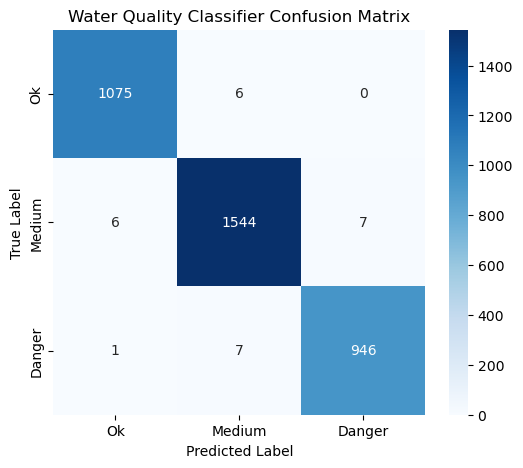

In [4]:
# 1. Generate predictions on the test set
y_pred = model.predict(X_test)

# 2. Print accuracy and precision/recall statistics
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Danger', 'Medium', 'Ok']))

# 3. Plot a visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Ok', 'Medium', 'Danger'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Ok', 'Medium', 'Danger'], 
    yticklabels=['Ok', 'Medium', 'Danger']
)
plt.title('Water Quality Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

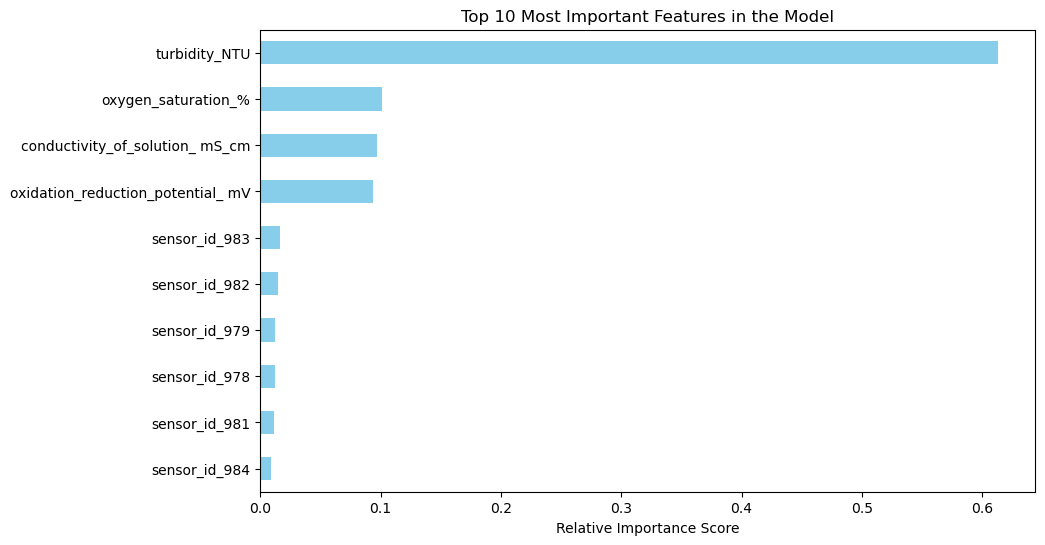

Model successfully exported as 'water_quality_random_forest.pkl'


In [5]:
# 1. Plot feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features in the Model')
plt.xlabel('Relative Importance Score')
plt.show()

# 2. Export the trained model to a file
# This is the file you would hand over to a backend developer for dashboard integration
joblib.dump(model, 'water_quality_random_forest.pkl')
print("Model successfully exported as 'water_quality_random_forest.pkl'")